In [75]:
from pathlib import Path
import time
from collections import deque

In [76]:
import numpy as np

In [77]:
import matplotlib.pyplot as plt

In [78]:
# # ----- Logger ----- #
# from loguru import logger
# import time
# logger.add("log.txt")

# from contextlib import contextmanager
# @contextmanager
# def timer(name):
#     t0 = time.time()
#     yield
#     logger.info(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [79]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID

        self.total_size = sum(len(g) for g in self.grids)
        self._score = 0
        self.score = 10 ** 9
    
    def query1(self, coordinate):
        x, y = coordinate
        self._score += 1
        return self.ans_grid[y][x]

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for x, y in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        x = rng.normal(mu, sigma)
        self._score += 1 / np.sqrt(k)
        return max(0, round(x))

    def answer(self, coordinates):
        is_ok = self.total_size == sum(self.ans_grid[y][x] for x, y in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok

In [80]:
def is_out_of_range(x, y, N):
    return not ((0 <= x < N) and (0 <= y < N))

In [81]:
class InformationVolumeSolver:
    
    """
        情報量を下げるように探索をする
    """

    def __init__(self, env: Env, N:int, M:int):
        self.env: Env = env
        self.N = N
        self.M = M

        self._init_infos()
        
    def _init_infos(self):
        placements_grid_num_dict = {}
        placements_proba_dict = {}

        for m in range(self.env.M):
            placements_grid_set = [[set() for _ in range(self.N)] for _ in range(self.N)]
            placements_proba = np.zeros((self.N, self.N), dtype=np.float64)
            target_grids = self.env.grids[m]
            t = 0
            for x in range(self.N):
                for y in range(self.N):
                    tmp_grids = []
                    is_ok = True
                    for coordinate in target_grids:
                        nx, ny = coordinate[0] + x, coordinate[1] + y
                        if is_out_of_range(nx, ny, self.N):
                            is_ok = False
                            break
                        tmp_grids.append((nx, ny))
                    if not is_ok:
                        continue
                    for coordinate in tmp_grids:
                        tx, ty = coordinate
                        placements_grid_set[ty][tx].add((x, y))
                    placements_proba[y][x] = 1
                    t += 1
            placements_grid_num_dict[m] = placements_grid_set
            placements_proba_dict[m] = placements_proba / t

        self.placements_grid_num_dict = placements_grid_num_dict
        self.placements_proba_dict = placements_proba_dict

    def _calc_mean_infomation_value(self, probs):
        ret = 0
        for prob in probs:
            if prob > 0:
                ret -= prob * np.log2(prob)
        return ret / len(probs)
    
    def calc_most_infomation_point(self):
        best_point = None
        best_score = 0
        for x in range(self.N):
            for y in range(self.N):
                probs = [self.placements_proba_dict[m][y][x] for m in range(self.M)]
                mean_infomation_value = self._calc_mean_infomation_value(probs)
                if best_score < mean_infomation_value:
                    best_score = mean_infomation_value
                    best_point = x, y
        return best_point
                    
    def update_prob_map(self, update_coordinate, resp_val):
        for m in range(self.M):
            total_num = 0
            total_prob = 0
            for x in range(self.N):
                for y in range(self.N):
                    if update_coordinate in self.placements_grid_num_dict[m][y][x]:
                        total_num += 1
                        total_prob += self.placements_proba_dict[m][y][x]
            not_num = self.N ** 2 - total_num
            not_prob = 1- total_prob
            if total_num == 0 or total_prob == 0:
                continue
            if resp_val == 0:
                for x in range(self.N):
                    for y in range(self.N):
                        if update_coordinate in self.placements_grid_num_dict[m][y][x]:
                            self.placements_proba_dict[m][y][x] = 0
                        else:
                            self.placements_proba_dict[m][y][x] *= 1/not_prob
                continue
            
            p1 = (self.N**2) / (self.M * total_num)
            p2 = (self.N**2 * (self.M-1)) / self.M*not_num
            std_fact = 1 / (total_prob * p1 + not_prob * p2)
            p1 *= std_fact
            p2 *= std_fact
            
            for x in range(self.N):
                for y in range(self.N):
                    if update_coordinate in self.placements_grid_num_dict[m][y][x]:
                        self.placements_proba_dict[m][y][x] = self.placements_proba_dict[m][y][x] * p1
                    else:
                        self.placements_proba_dict[m][y][x] = self.placements_proba_dict[m][y][x] * p2



In [82]:
env = Env(file_path = Path(f"./in/0005.txt"))

In [83]:
solver = InformationVolumeSolver(env=env, N=env.N, M=env.M)

----- 0 -----


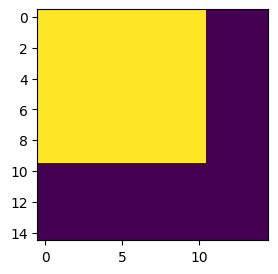

----- 100 -----


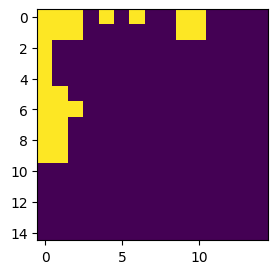

----- 200 -----


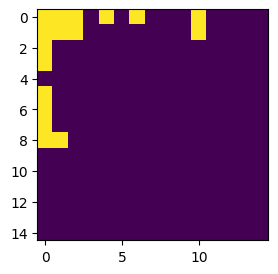

----- 300 -----


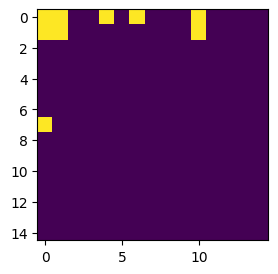

----- 400 -----


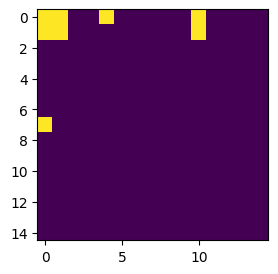

----- 500 -----


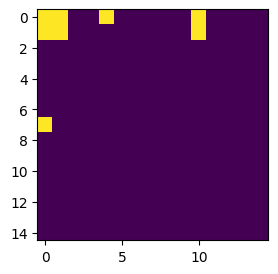

----- 600 -----


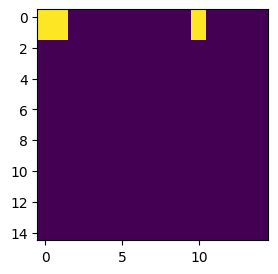

----- 700 -----


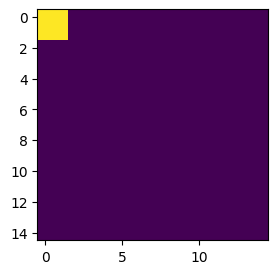

----- 800 -----


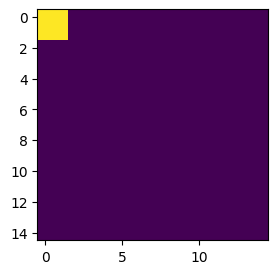

----- 900 -----


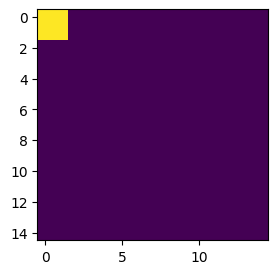

----- 1000 -----


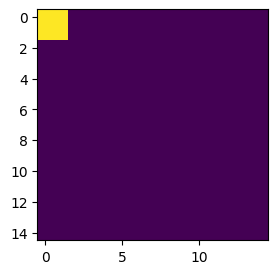

----- 1100 -----


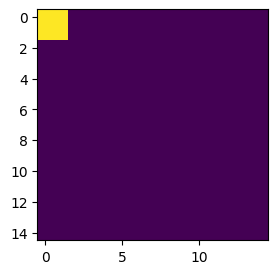

----- 1200 -----


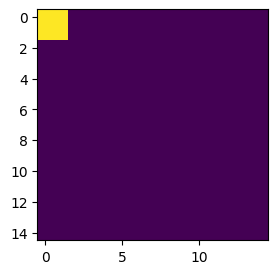

----- 1300 -----


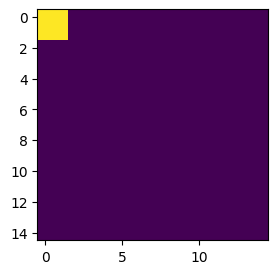

----- 1400 -----


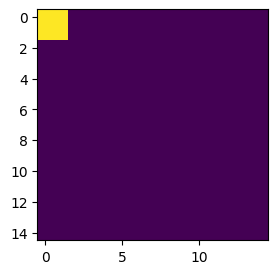

----- 1500 -----


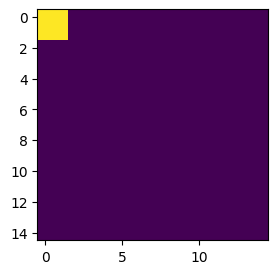

----- 1600 -----


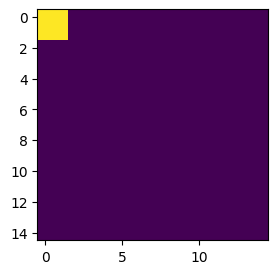

----- 1700 -----


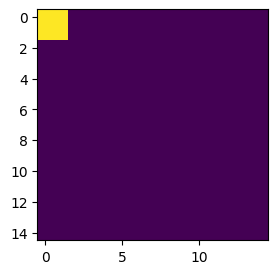

----- 1800 -----


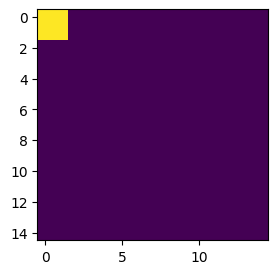

----- 1900 -----


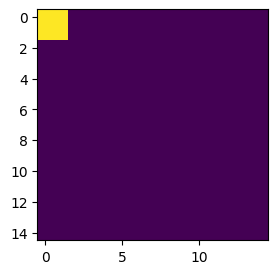

----- 2000 -----


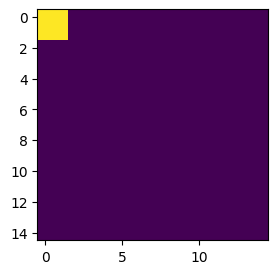

----- 2100 -----


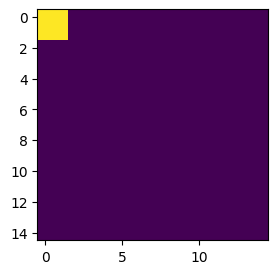

----- 2200 -----


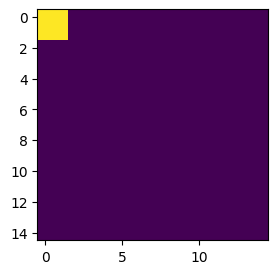

----- 2300 -----


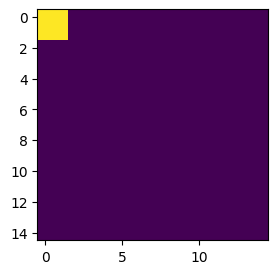

----- 2400 -----


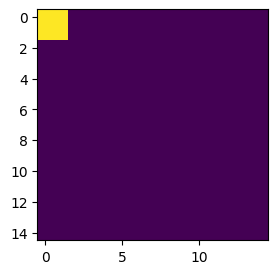

----- 2500 -----


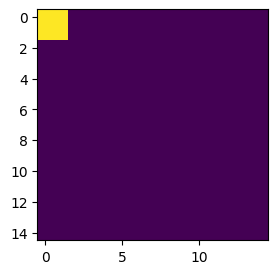

----- 2600 -----


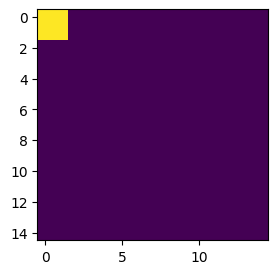

----- 2700 -----


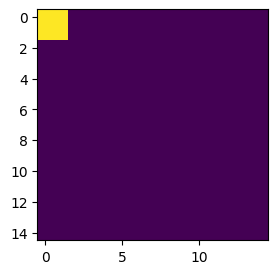

----- 2800 -----


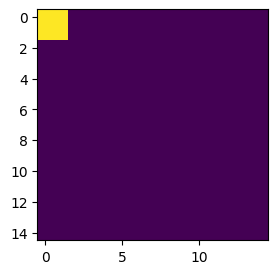

----- 2900 -----


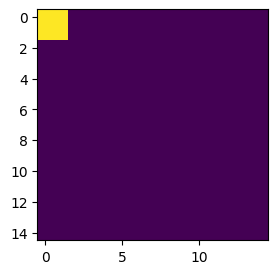

----- 3000 -----


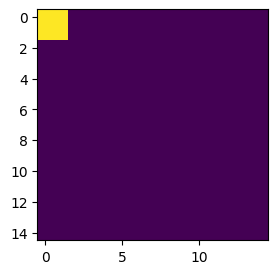

----- 3100 -----


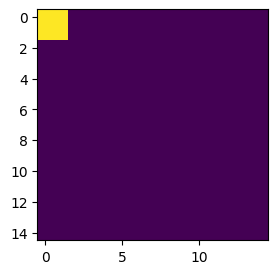

----- 3200 -----


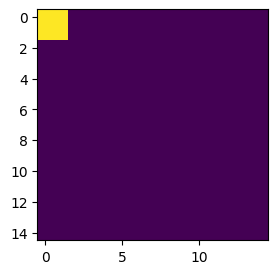

----- 3300 -----


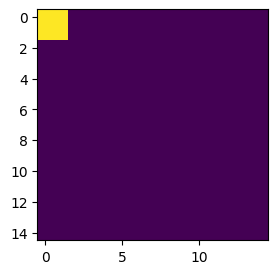

----- 3400 -----


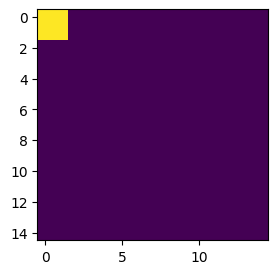

----- 3500 -----


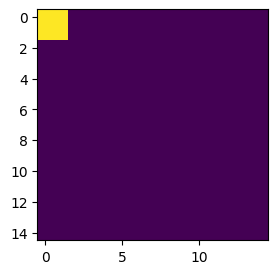

----- 3600 -----


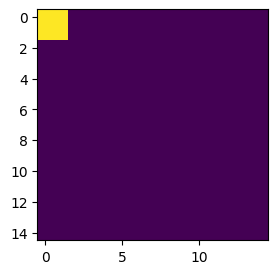

----- 3700 -----


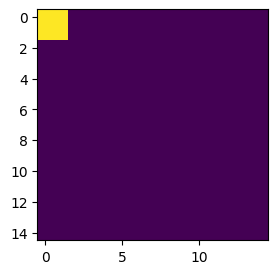

----- 3800 -----


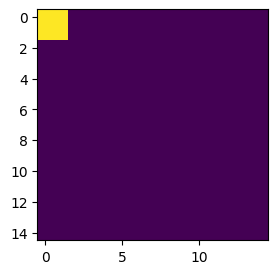

----- 3900 -----


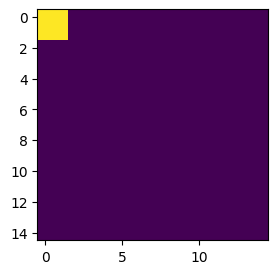

----- 4000 -----


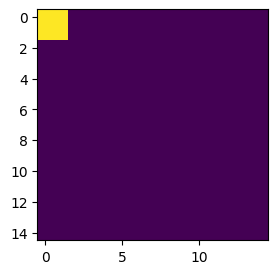

----- 4100 -----


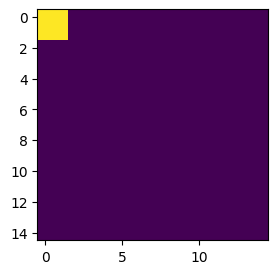

----- 4200 -----


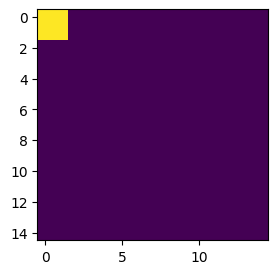

----- 4300 -----


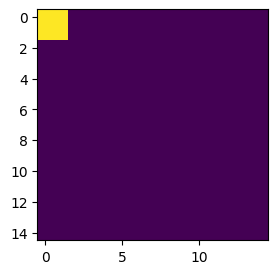

----- 4400 -----


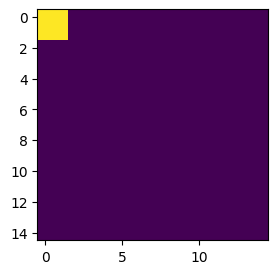

----- 4500 -----


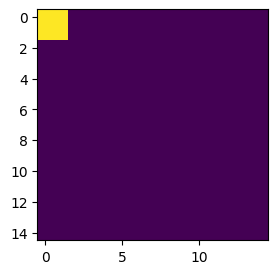

----- 4600 -----


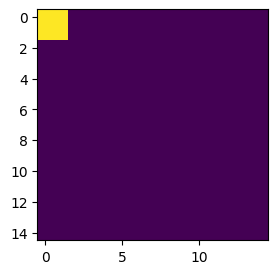

----- 4700 -----


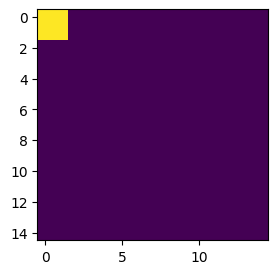

----- 4800 -----


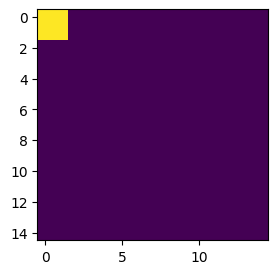

----- 4900 -----


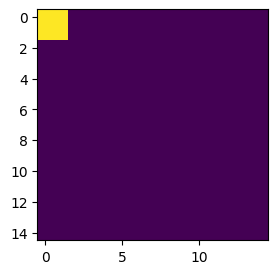

----- 5000 -----


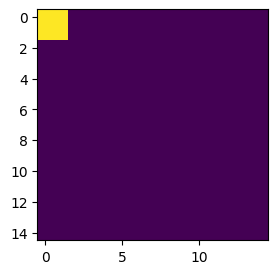

----- 5100 -----


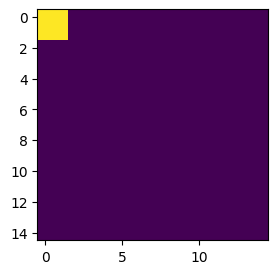

----- 5200 -----


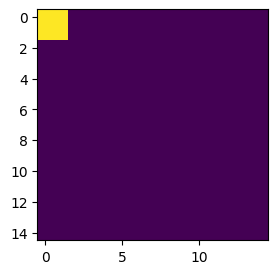

----- 5300 -----


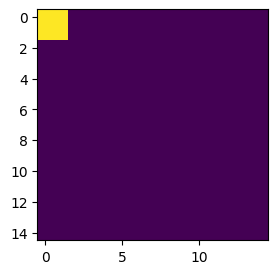

----- 5400 -----


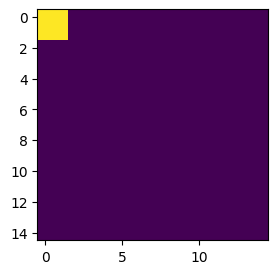

----- 5500 -----


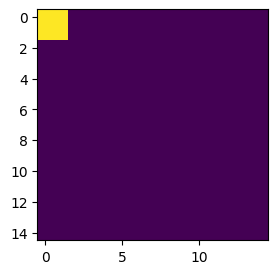

----- 5600 -----


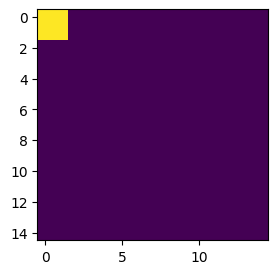

----- 5700 -----


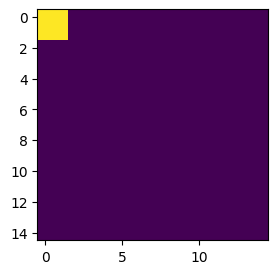

----- 5800 -----


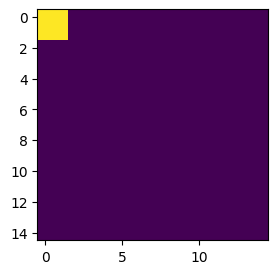

----- 5900 -----


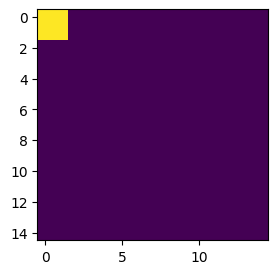

----- 6000 -----


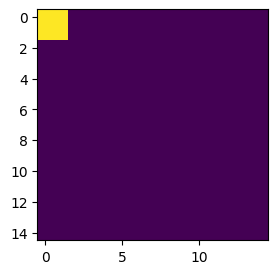

----- 6100 -----


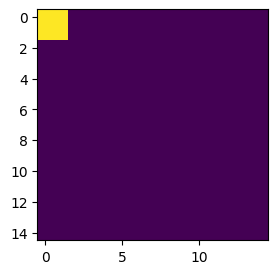

----- 6200 -----


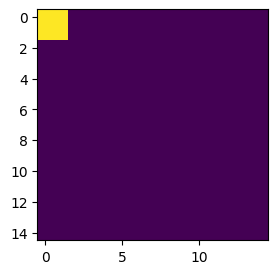

----- 6300 -----


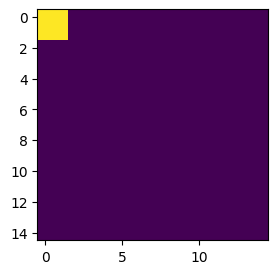

----- 6400 -----


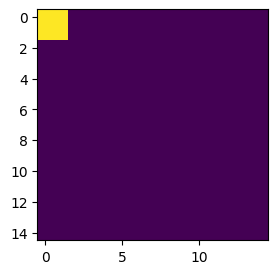

----- 6500 -----


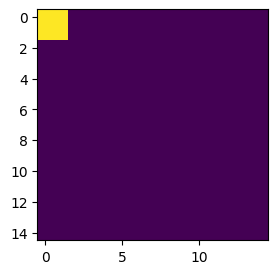

----- 6600 -----


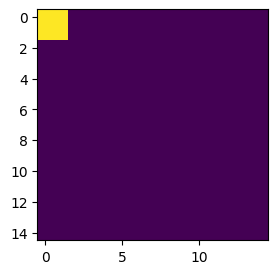

----- 6700 -----


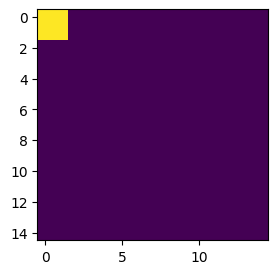

----- 6800 -----


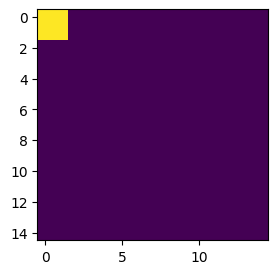

----- 6900 -----


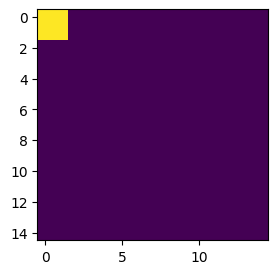

----- 7000 -----


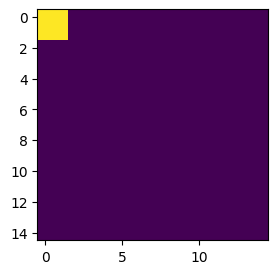

----- 7100 -----


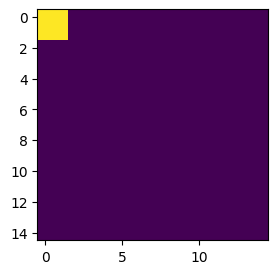

----- 7200 -----


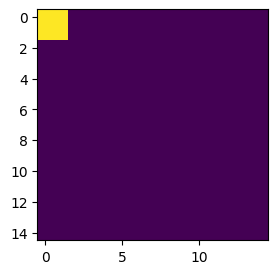

----- 7300 -----


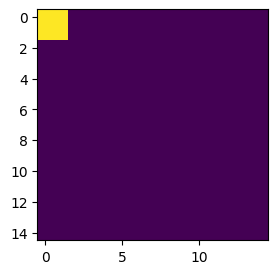

----- 7400 -----


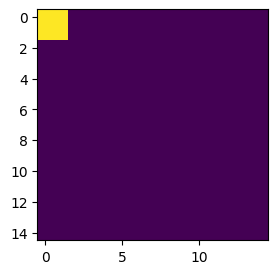

----- 7500 -----


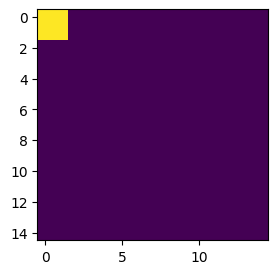

----- 7600 -----


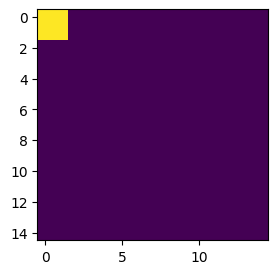

----- 7700 -----


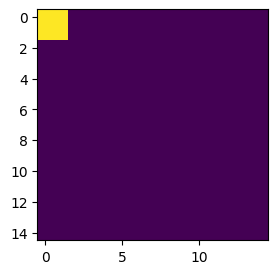

----- 7800 -----


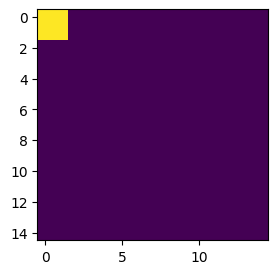

----- 7900 -----


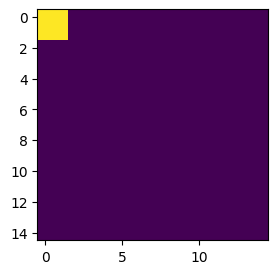

----- 8000 -----


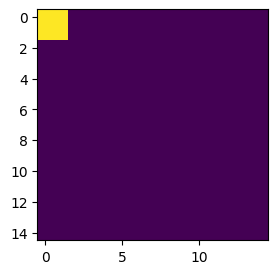

----- 8100 -----


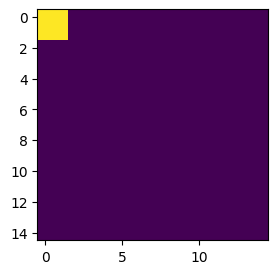

----- 8200 -----


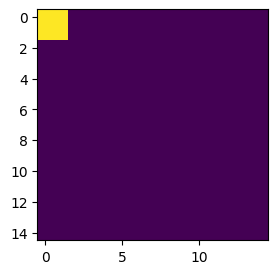

----- 8300 -----


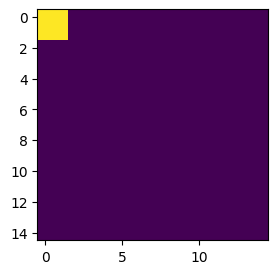

----- 8400 -----


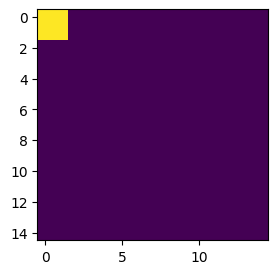

----- 8500 -----


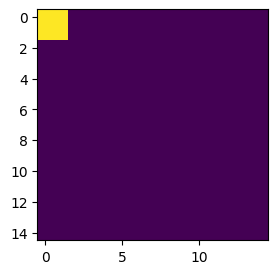

----- 8600 -----


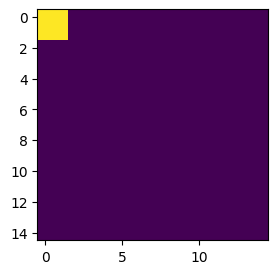

----- 8700 -----


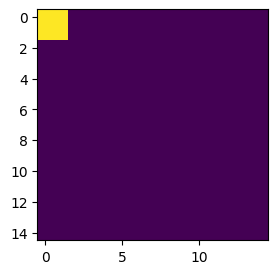

----- 8800 -----


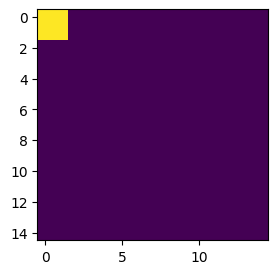

----- 8900 -----


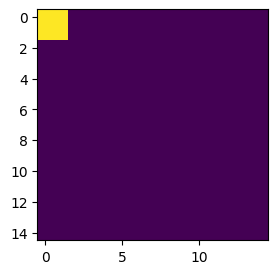

----- 9000 -----


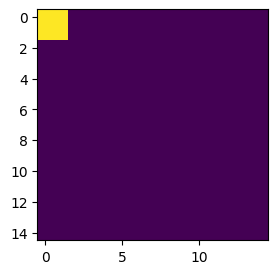

----- 9100 -----


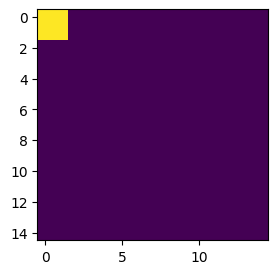

----- 9200 -----


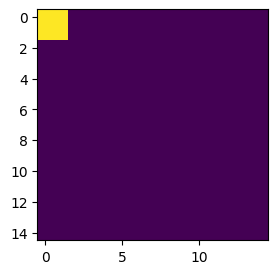

----- 9300 -----


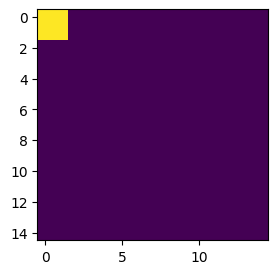

----- 9400 -----


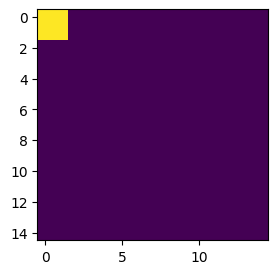

----- 9500 -----


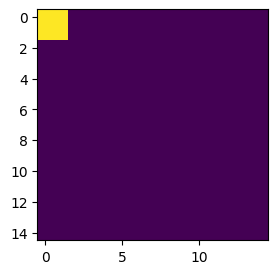

----- 9600 -----


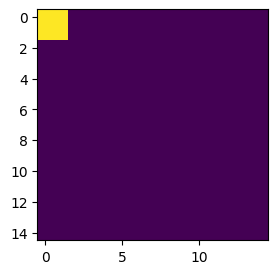

----- 9700 -----


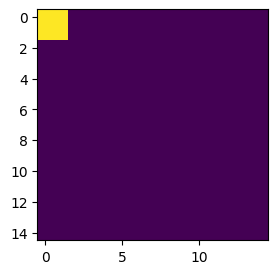

----- 9800 -----


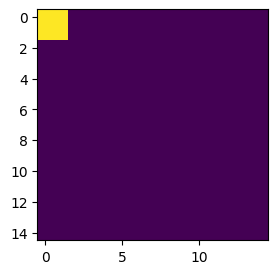

----- 9900 -----


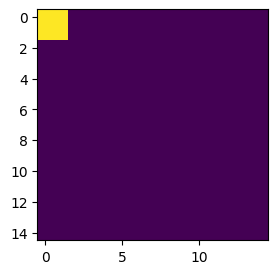

In [84]:
import random
for i in range(10000):
    t = random.randint(0, env.N**2 -1)
    # x, y = solver.calc_most_infomation_point()
    # print(x, y)
    x, y = t % env.N, t // env.N 
    resp = env.query1((x, y))
    solver.update_prob_map((x, y), resp)
    if i % 100 == 0:
        print(f"----- {i} -----")
        plt.figure(figsize=(3,3))
        plt.imshow(solver.placements_proba_dict[0])
        plt.show()

In [85]:
np.max(solver.placements_proba_dict[0])


0.24999999999999892

In [89]:
solver.placements_proba_dict[0]

array([[2.50000000e-001, 2.50000000e-001, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [2.50000000e-001, 2.50000000e-001, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
        0.00000000e+000, 0.00000000e+000, 0.00000000e

In [86]:
# def grid_print(g):
#     for l in g:
#         print(" ".join(map(str, l)))

# def plot_grid2(grid):
#     x_list = []
#     y_list = []
#     for coordinate in grid:
#         x, y = coordinate
#         x_list.append(x)
#         y_list.append(y)
#     x_max = max(x_list)
#     y_max = max(y_list)
#     disp_grid = [["." for _ in range(x_max+1)] for _ in range(y_max+1)]
#     for coordinate in grid:
#         tx, ty = coordinate
#         disp_grid[ty][tx] = "#"
#     for line in disp_grid:
#         print("".join(line))
        
# def grid_proba_print(g):
#     for l in g:
#         print(" ".join([f"{v:.3f}" for v in l]))

In [87]:
# placements_grid_prob_dict = {}
# for m in range(env.M):
#     placements_grid_prob_dict[m] = placements_grid_num_dict[m] / placements_sum_dict[m]

# grid_info_volume = np.zeros((env.N, env.N))
# for x in range(env.N):
#     for y in range(env.N):
#         for m in range(env.M):
#             prob = placements_grid_prob_dict[m][x][y]
#             if prob > 0:
#                 grid_info_volume[x][y] -= prob * np.log2(prob)

# np.unravel_index(np.argmax(grid_info_volume), grid_info_volume.shape)

In [88]:
# scores = []
# for test_num in range(100):

#     try:
#         env = Env(file_path = Path(f"./in/{test_num:0>4}.txt"))
#         grid_env = BFSSolver(env.N, total_oil_num=env.total_size)
#         for i in range(100000):
#             x, y = grid_env.get_next_search_point()
#             v = env.query1((x, y))
#             grid_env.response(x, y, v)
#             if grid_env.is_ok():
#                 env.answer(grid_env.get_plus_grids())
#                 break
#     except Exception as e:
#         print(e)
#         scores.append(10**9)
#     scores.append(env.score)

# plt.figure(figsize=(10, 5))
# plt.bar(list(range(len(scores))), scores)
# plt.show()

# print(sum(scores) / len(scores))